# Week 4 - Univariate Analysis, part 2

# 1. Lesson - None

# 2. Weekly graph question

Below are a histogram and boxplot representation of the same data. A pharmacy is keeping a record of the prices of the drugs that it sells, and an administrator wants to know how much the more expensive drugs tend to cost, in the context of the other prices.

Please write a short explanation of the pros and cons of these two representations. Which would you choose? How would you modify the formatting, if at all, to make it more visually interesting, clear, or informative?

In [2]:
import numpy as np
import pandas as pd

np.random.seed(0)
num_data = 100
data = np.exp(np.random.uniform(size = num_data) * 4)
df = pd.DataFrame(data.T, columns = ["data"])

The 75th percentile is: data    15.457656
Name: 0.75, dtype: float64


<Axes: ylabel='Frequency'>

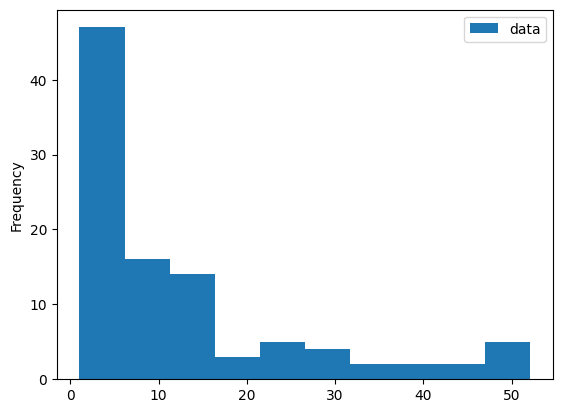

In [3]:
print("The 75th percentile is:", df.quantile(q = 0.75))
df.plot.hist()

<Axes: >

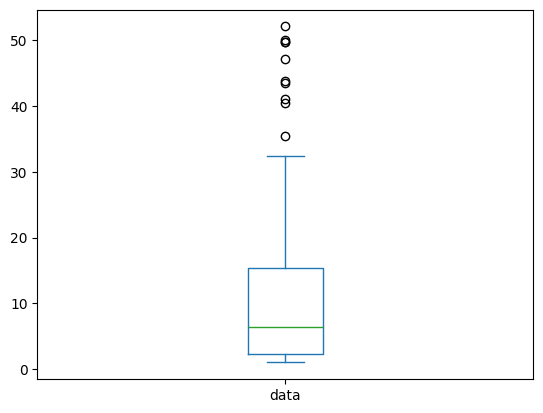

In [4]:
df.plot.box()

Histogram
Pros: Easy to see the overall distribution of drug prices. Easy to see where most prices cluster and that the data is right skewed. 
Cons: Exact values like the median, percentiles, and outleirs aren't obvious. 
To make this graph more clear, I would add a y label "Number of Drugs Purchased", x label "Drug Price", title "Distribution of Drug Prices", and add data labels on the number of frequency. 

Box Plot
Pros: It is easy to identify the minimum, maximum, and median. This plot does answerthe question of how expesnive drugs compare to the rest. 
Cons: It does not show frequency details and it does not feel as intuitive compared to the histogram. Outliers are shown as points and you do not see how prices are dstributed within the main distribution of prices. 
To make this graph more clear I would annotate the mediean and percentile values, add a y label "Drug Prices", and a title "Drug Price Range".

I would prefer the histogram as it shows the different price ranges better and it is easier to understand. 

# 3. Homework - working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Draw histograms and histogram variants for each feature or column.  (Swarm plot, kde plot, violin plot).

- Draw grouped histograms.  For instance, if you have tree heights for both maple and oak trees, you could draw histograms for both.

- Draw a bar plot to indicate total counts of each categorical variable in a given column.

- Find means, medians, and modes.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If they are not useable, find some new data!

- What is the overall shape of the distribution?  Is it normal, skewed, bimodal, uniform, etc.?

- Are there any outliers present?  (Data points that are far from the others.)

- If there are multiple related histograms, how does the distribution change across different groups?

- What are the minimum and maximum values represented in each histogram?

- How do bin sizes affect the histogram?  Does changing the bin width reveal different patterns in the data?

- Does the distribution appear normal, or does it have a different distribution?

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
#df_flight = pd.read_csv("flight_data.csv", encoding="latin1")
df_flight = pd.read_csv("weather_airline_delay.csv", encoding="latin1")

#mean, median, and mode calcs dropping strings, and date
columns_to_drop = ["CARRIER_NAME","DEPARTING_AIRPORT", "PREVIOUS_AIRPORT", "DEP_TIME_BLK"]
df_calc = df_flight.drop(columns_to_drop, axis=1)
print(df_calc.mean())
print(df_calc.median())
print(df_calc.mode().iloc[0])

MONTH                            6.661566e+00
DAY_OF_WEEK                      3.964996e+00
DEP_DEL15                        1.946195e-01
DISTANCE_GROUP                   3.858486e+00
SEGMENT_NUMBER                   3.054705e+00
CONCURRENT_FLIGHTS               2.822692e+01
NUMBER_OF_SEATS                  1.344311e+02
AIRPORT_FLIGHTS_MONTH            1.275218e+04
AIRLINE_FLIGHTS_MONTH            6.272816e+04
AIRLINE_AIRPORT_FLIGHTS_MONTH    3.521278e+03
AVG_MONTHLY_PASS_AIRPORT         1.599575e+06
AVG_MONTHLY_PASS_AIRLINE         7.843445e+06
FLT_ATTENDANTS_PER_PASS          1.000513e-04
GROUND_SERV_PER_PASS             1.364934e-04
PLANE_AGE                        1.160426e+01
LATITUDE                         3.669463e+01
LONGITUDE                       -9.440880e+01
PRCP                             1.045535e-01
SNOW                             3.252325e-02
SNWD                             9.291929e-02
TMAX                             7.129883e+01
AWND                             8

3.964996499649965
4.0
5


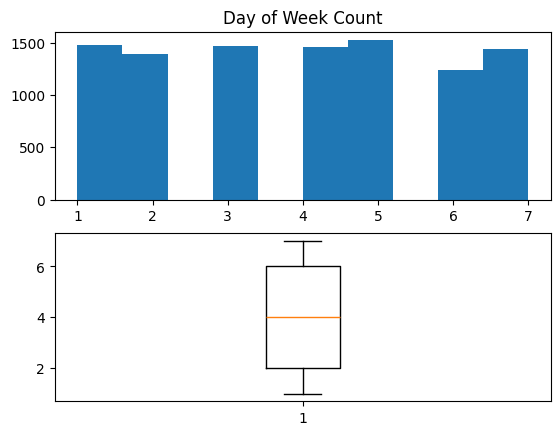

In [6]:
# histograms for the Date. I did not add day of the week 
fig, (ax1, ax2) = plt.subplots(2)
ax1.hist(df_flight["DAY_OF_WEEK"])
ax1.set_title("Day of Week Count")

ax2.boxplot(df_flight["DAY_OF_WEEK"])

print(df_flight["DAY_OF_WEEK"].mean())
print(df_flight["DAY_OF_WEEK"].median())
print(df_flight["DAY_OF_WEEK"].mode().iloc[0])

For the Day of Week Count the distribution looks normal. The minimum values for the counts just show that there weren't as many flights and the most represent there was a peak in travel those weeks. Adjusting the bin size would not help as tehre are only 7 weeks displayed. 

1308.3039303930393
1300.0
800


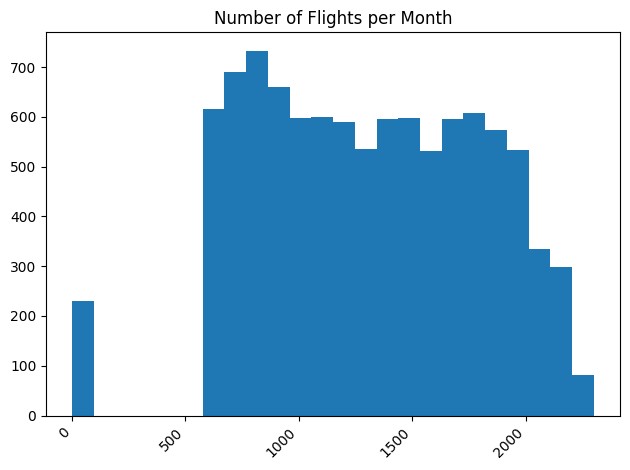

In [7]:
#Histogram for the Date
#fig, (ax1, ax2) = plt.subplots(2)
df_flight["DEP_TIME_HR"]=df_flight["DEP_TIME_BLK"].astype(str).str.split("-", expand=True)[0].astype(int)
plt.hist(df_flight["DEP_TIME_HR"], bins=24)
plt.xticks(rotation=45, ha="right") #Make the dates visible
plt.title("Number of Flights per Month")
plt.tight_layout()
#ax1.set_title("Date Count")


print(df_flight["DEP_TIME_HR"].mean())
print(df_flight["DEP_TIME_HR"].median())
print(df_flight["DEP_TIME_HR"].mode().iloc[0])

In [8]:
sns.violinplot(df_flight["SCHEDULED_DEPARTURE"])
plt.title("Number of Flights per Month")


KeyError: 'SCHEDULED_DEPARTURE'

The histogram's distribution is skewed right for the number of flights per month. I believe the outlier data is in 12/2019, possibly from me cutting off the data at 10,000 rows. The min and max represent how many flights happened per month. Bin size could change the time duration to be daiily, weekly or monthly but I chose to group by months as it would be clearer to read. 

Text(0.5, 1.0, 'CONCURRENT_FLIGHTS')

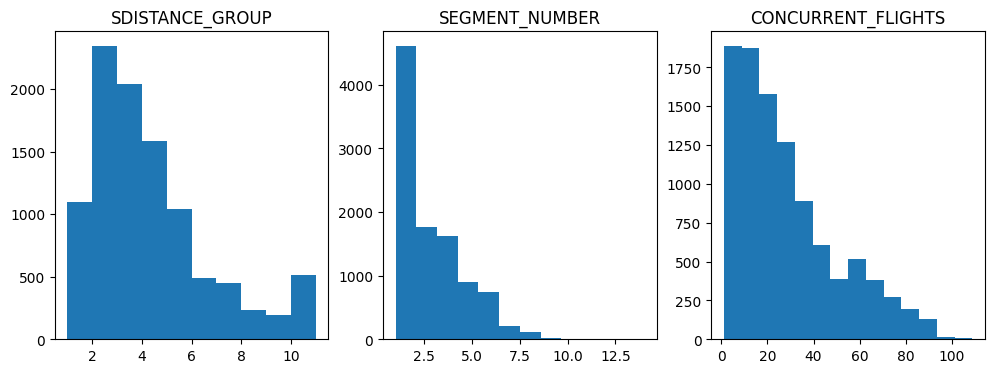

In [ ]:

fig, axs = plt.subplots (1, 3, figsize=(12,4))
axs[0].hist(df_flight["DISTANCE_GROUP"], bins =10)
axs[0].set_title("SDISTANCE_GROUP")
axs[1].hist(df_flight["SEGMENT_NUMBER"], bins =12)
axs[1].set_title("SEGMENT_NUMBER")
axs[2].hist(df_flight["CONCURRENT_FLIGHTS"], bins =14)
axs[2].set_title("CONCURRENT_FLIGHTS")



All three histograms distributions above are skewed left. I would not say there are any outliers present but it shows that most flights happen somwhere between 1200-2000. The minimum and maximum values represent how many flights depart or arrive per hour. The bin sizes do affect the histogram as you get finer details with the distribution based on how many bins of time you would like to create. (Middle one is 12 bins and the other ones are 24 bins). I would say the CRS arrival time has a bimodal peaks but overall all are skewed left. 

<Axes: ylabel='SCHEDULED_ARRIVAL'>

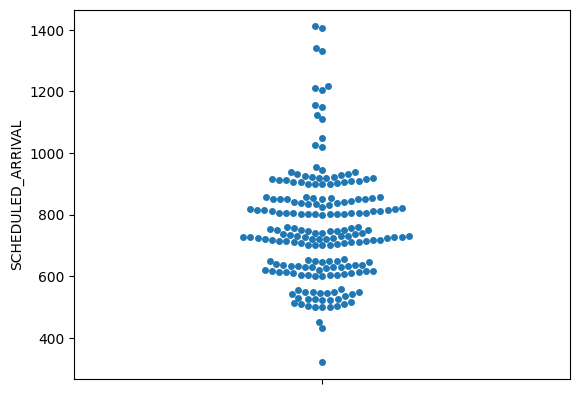

In [ ]:
limit_arrtime = df_flight["SCHEDULED_ARRIVAL"].iloc[:200] #limit length to plot using swarmplot 
sns.swarmplot(limit_arrtime)

<Axes: ylabel='ARRIVAL_TIME'>

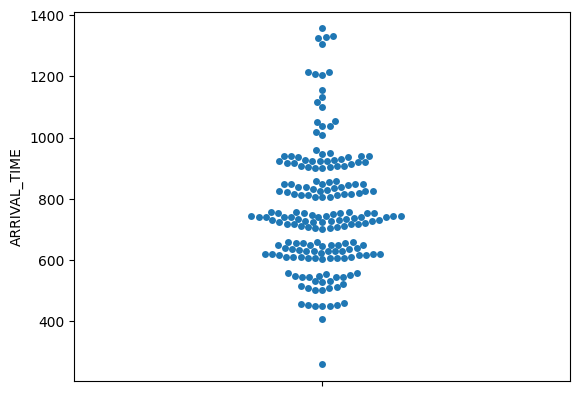

In [ ]:
limit_crsarr = df_flight["ARRIVAL_TIME"].iloc[:200]
sns.swarmplot(limit_crsarr)

Text(0.5, 1.0, 'AWND')

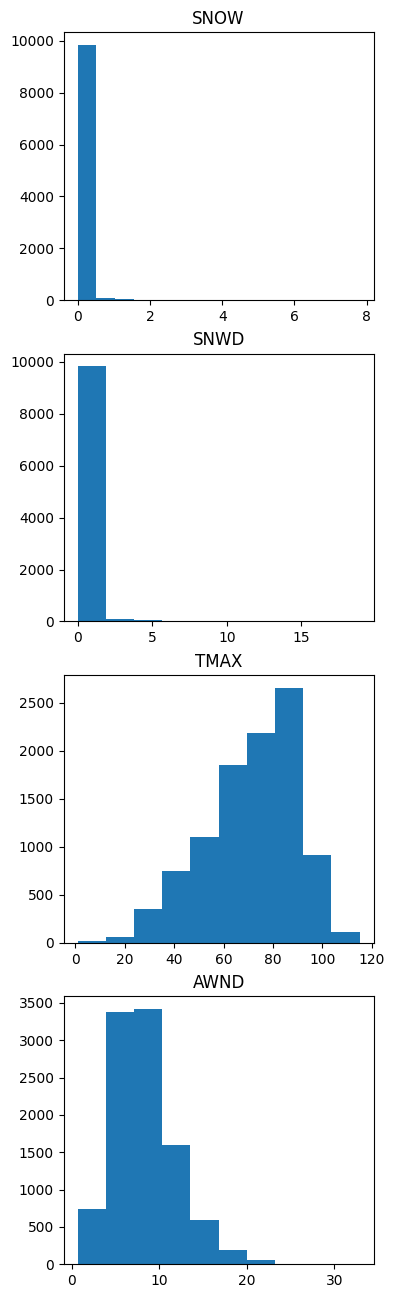

In [ ]:
#skipped UniqueCarrier and Airline as the data is all from Southwest Airlines.
fig, axs = plt.subplots (4, 1, figsize=(4,16))
axs[0].hist(df_flight["SNOW"], bins=15)
axs[0].set_title("SNOW")
axs[1].hist(df_flight["SNWD"])
axs[1].set_title("SNWD")
axs[2].hist(df_flight["TMAX"])
axs[2].set_title("TMAX")
axs[3].hist(df_flight["AWND"])
axs[3].set_title("AWND")



Text(0.5, 1.0, 'DEP_BLOCK_HIST')

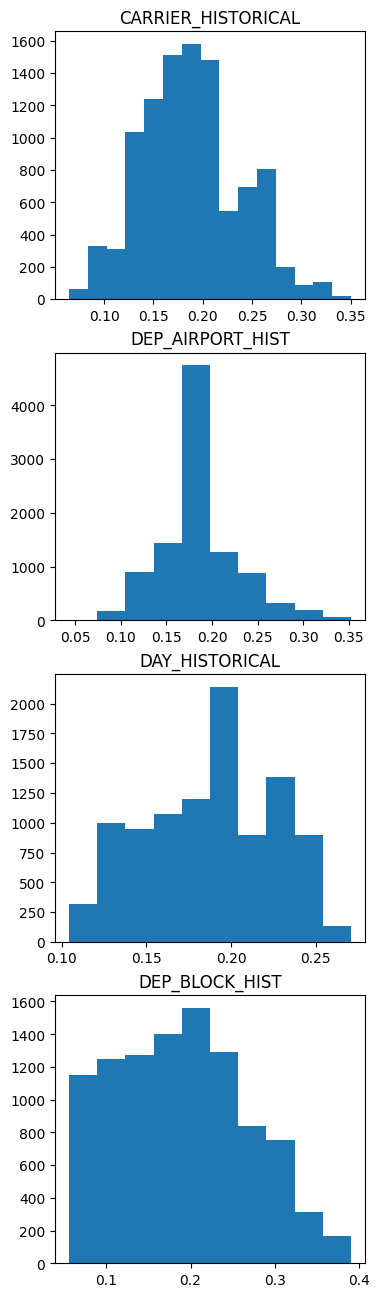

In [ ]:
fig, axs = plt.subplots (4, 1, figsize=(4,16))
axs[0].hist(df_flight["CARRIER_HISTORICAL"], bins=15)
axs[0].set_title("CARRIER_HISTORICAL")
axs[1].hist(df_flight["DEP_AIRPORT_HIST"])
axs[1].set_title("DEP_AIRPORT_HIST")
axs[2].hist(df_flight["DAY_HISTORICAL"])
axs[2].set_title("DAY_HISTORICAL")
axs[3].hist(df_flight["DEP_BLOCK_HIST"])
axs[3].set_title("DEP_BLOCK_HIST")

All the graph distributions above are skewed right. I would say there are no outliers with some of the data. The time in flight makes sense within the 48 states as most flights were not above 6 hrs. The delays do have outliers with very few above 100 minutes of delay. The distributions here are a similar group and do not change much with time in flight and delays. The minimum and maximum for time of flgith is the number of flights in minutes they are in air. For delays its how long it has been delayed. The bin brings finer detail of time distribution to all the graphs above. 

<Axes: ylabel='ActualElapsedTime'>

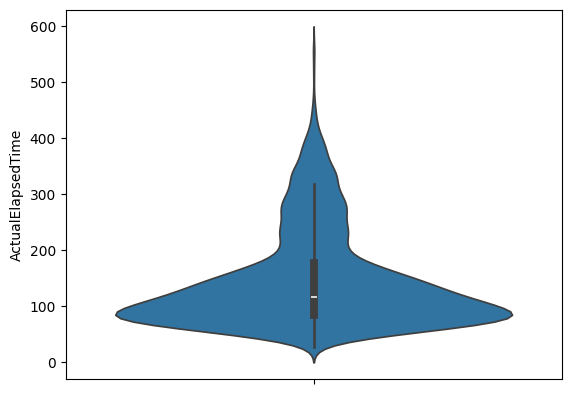

In [ ]:
sns.violinplot(df_flight["ActualElapsedTime"])


<Axes: ylabel='CRSElapsedTime'>

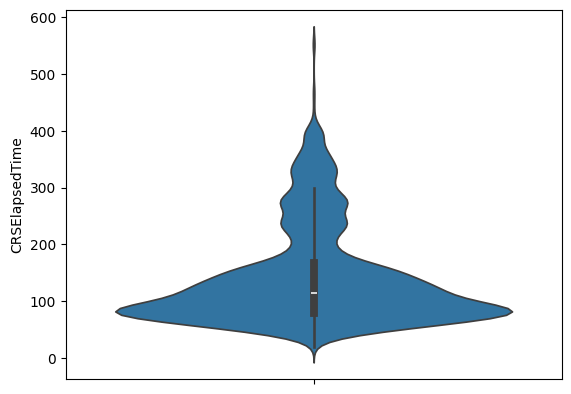

In [ ]:
sns.violinplot(df_flight["CRSElapsedTime"])

<Axes: ylabel='AirTime'>

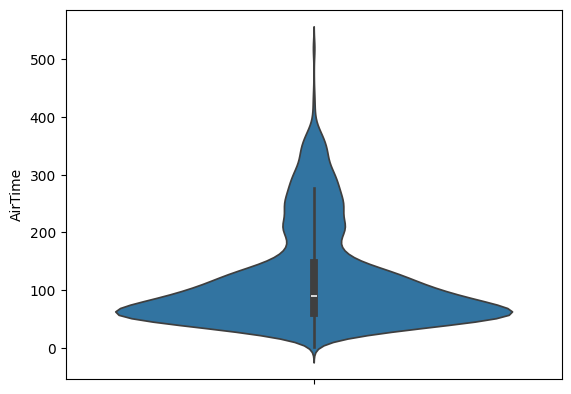

In [ ]:
sns.violinplot(df_flight["AirTime"])

<Axes: ylabel='ArrDelay'>

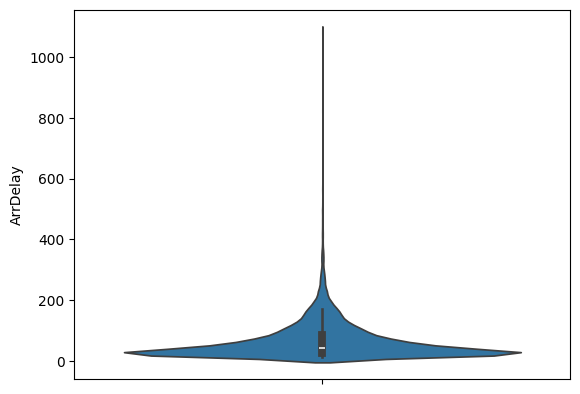

In [ ]:
sns.violinplot(df_flight["ArrDelay"])

<Axes: ylabel='DepDelay'>

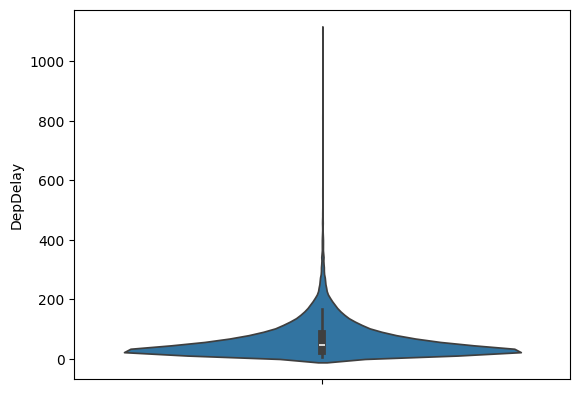

In [ ]:
sns.violinplot(df_flight["DepDelay"])

Text(0.5, 1.0, 'Top 10 Departing Airports')

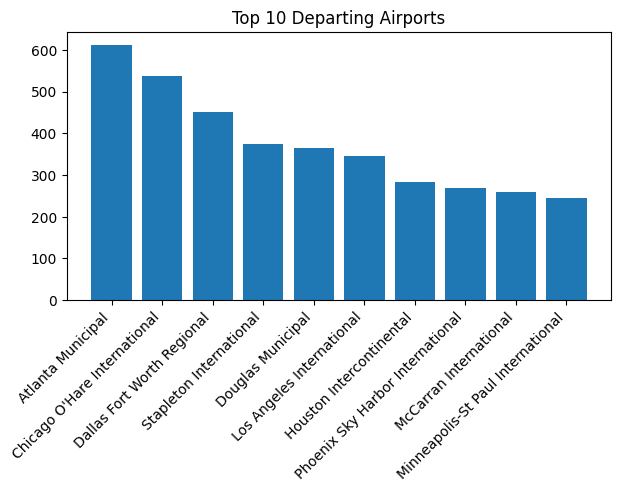

In [ ]:
#Combined Origin and Org_Airport as the data was the same
#unique=df_flight["ORIGIN_AIRPORT"].unique
#df_flight_fixed = df_flight.copy()
#one_hot = pd.get_dummies(df_flight["ORIGIN_AIRPORT"], dtype=int)
#df_flight_fixed = df_flight.join(one_hot)
#df_flight_fixed.iloc[0:5]

top = df_flight["DEPARTING_AIRPORT"].value_counts().head(10)
plt.bar(top.index, top.values)
plt.xticks(rotation=45, ha="right") 
plt.tight_layout()
plt.title("Top 10 Departing Airports")

The distribution for the origin airports is skewed left but skew isnt the best word here becasue it is a ranking chart. I would say there are no outliers as the data would make sense as the most used airports are from large cities. This distribution is very similar to the Destination airport and the distribution looks very similar. The minimum and maximum values represent how many times the origin airport is used for takeoff. The bin size affects the number of airports on the graphs.

Text(0.5, 1.0, 'Top 10 Origin Airports')

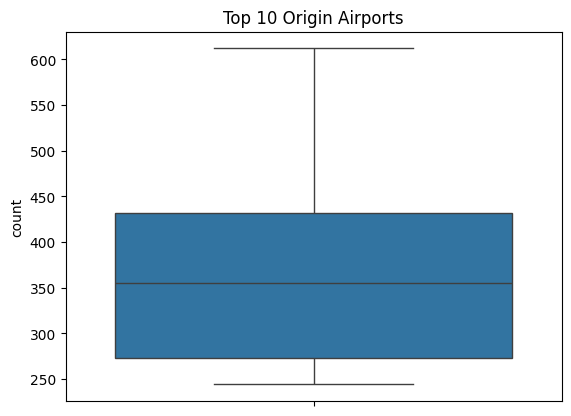

In [ ]:
sns.boxplot(top)
plt.title("Top 10 Origin Airports")

Text(0.5, 1.0, 'Top 10 Destination Airports')

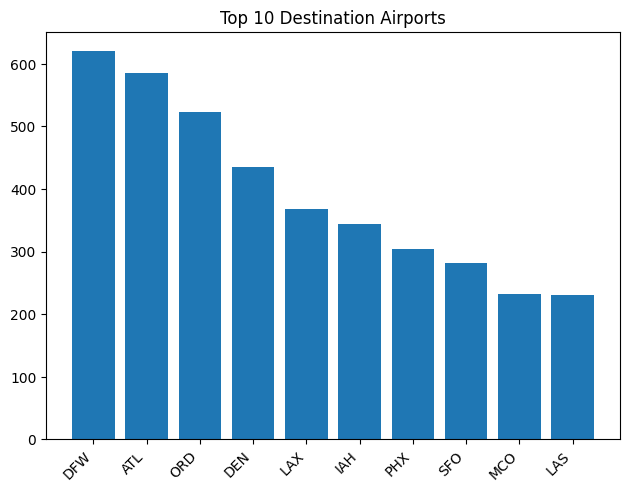

In [ ]:


top_dest = df_flight["DESTINATION_AIRPORT"].value_counts().head(10)
plt.bar(top_dest.index, top_dest.values)
plt.xticks(rotation=45, ha="right") 
plt.tight_layout()
plt.title("Top 10 Destination Airports")

Similar to oriigins, destiantions are concentrated among a few major airports. I would say there are no outliers as the data would make sense as the most used airports are from large cities. This distribution is very similar to the Origin airport and the distribution looks very similar. The minimum and maximum values represent how many times the departure airport is used for arrivals. The bin size affects teh number of airports on the graphs.

Text(0.5, 1.0, 'Top 10 Destination Airports')

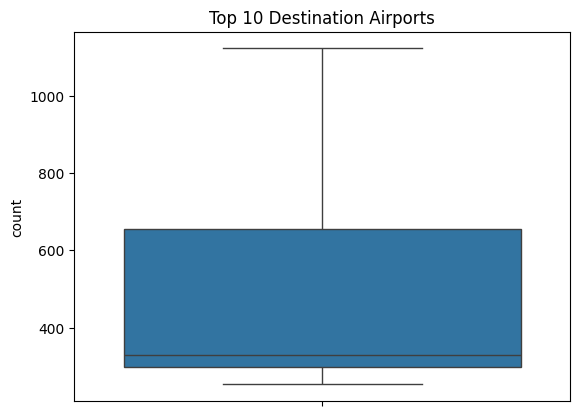

In [ ]:
sns.boxplot(top_dest)
plt.title("Top 10 Destination Airports")

Text(0.5, 1.0, 'Taxi Out Time')

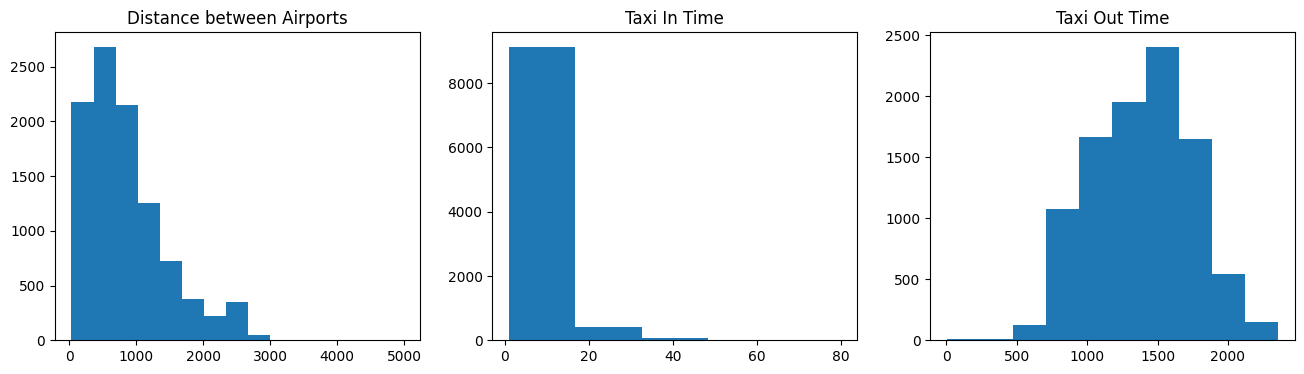

In [ ]:
#Did not plot cancelled, cancellation code, and divert as they did not have any unique value
fig, axs = plt.subplots (1, 3, figsize=(16,4))
axs[0].hist(df_flight["DISTANCE"], bins=15)
axs[0].set_title("Distance between Airports")
axs[1].hist(df_flight["TAXI_IN"], bins=5)
axs[1].set_title("Taxi In Time")
axs[2].hist(df_flight["WHEELS_ON"], bins=10)
axs[2].set_title("Taxi Out Time")


All the distributions in the histograms above are skewed right. The taxi in and out times have outliers after a certain point. The distance between airports does not have outliers but very uncommon distances. I would say the distance between airports matches the time of flight histograms as there were more shorter flights. The taxi in and out time are similar to dealys where there skwed right with it being uncommon to have long times. The minimum and maximum for distnace between airports represent miles between airports while the taxi in and out time are how long in minutes it takes for the aircraft to be taxied. The bin size does not affect taxi in and out times much as there is not many time distributions. For distance between airprots, you can break up the distance in miles in greater detail. 

<Axes: ylabel='Distance'>

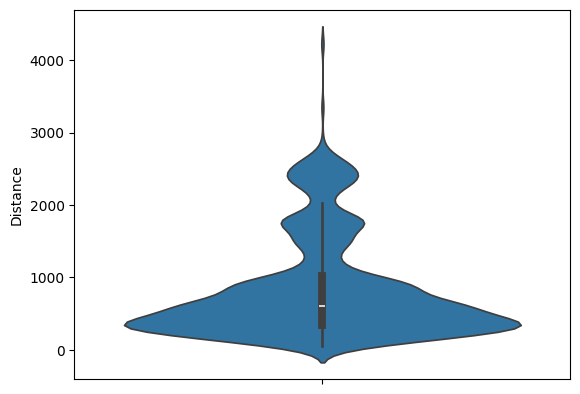

In [ ]:
sns.violinplot(df_flight["Distance"])

<Axes: ylabel='TaxiIn'>

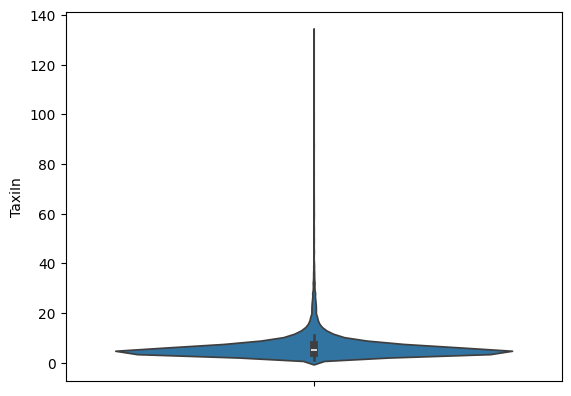

In [ ]:
sns.violinplot(df_flight["TaxiIn"])

<Axes: ylabel='TaxiOut'>

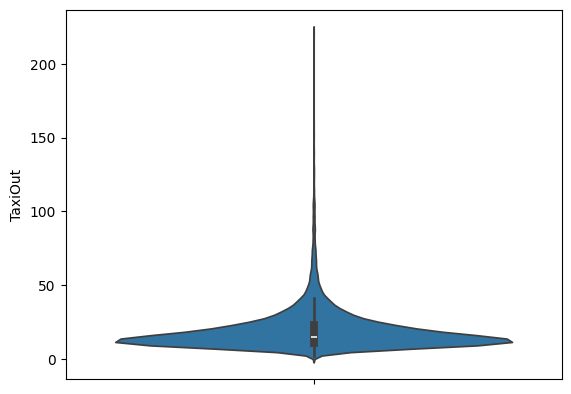

In [ ]:
sns.violinplot(df_flight["TaxiOut"])

Text(0.5, 1.0, 'Time Delayed by Aircraft Delay')

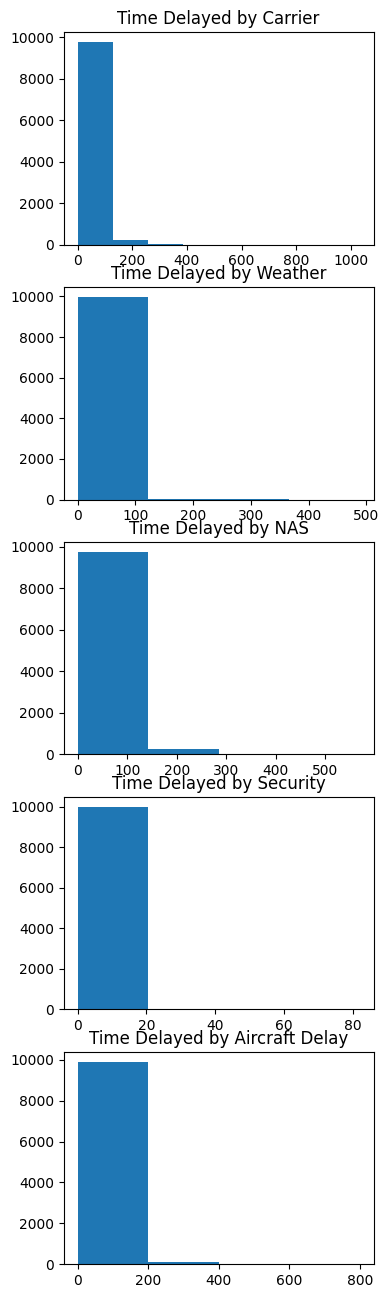

In [ ]:
#Plots for all the delay times
fig, axs = plt.subplots (5, 1, figsize=(4,16))
axs[0].hist(df_flight["CarrierDelay"], bins=8)
axs[0].set_title("Time Delayed by Carrier")
axs[1].hist(df_flight["WeatherDelay"], bins=4)
axs[1].set_title("Time Delayed by Weather")
axs[2].hist(df_flight["NASDelay"], bins=4)
axs[2].set_title("Time Delayed by NAS")
axs[3].hist(df_flight["SecurityDelay"], bins=4)
axs[3].set_title("Time Delayed by Security")
axs[4].hist(df_flight["LateAircraftDelay"], bins=4)
axs[4].set_title("Time Delayed by Aircraft Delay")

All of the delays are skewed right but I would say most of the data is concentrated left. So there are outliers above a certain time for each type of delay. This histrogram looks very similar to the departure and arrival delay where it is skewed to the right but all the data is concentrated left with anything to the right being outliers. The minimum and maximum values represent the length of time delayed. The bin sizes did not have much of affect to the graphs as most of the data is concentrated in certain time frames. 

<Axes: ylabel='CarrierDelay'>

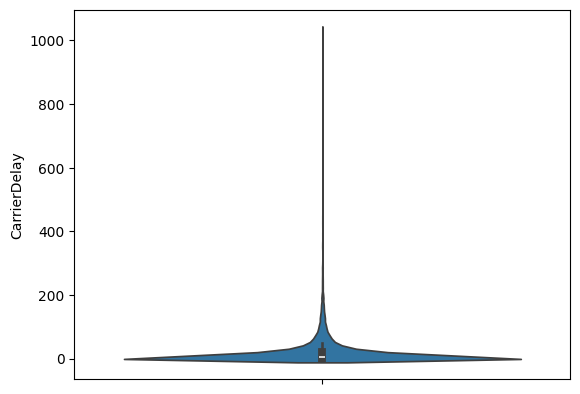

In [ ]:
sns.violinplot(df_flight["CarrierDelay"])

<Axes: ylabel='WeatherDelay'>

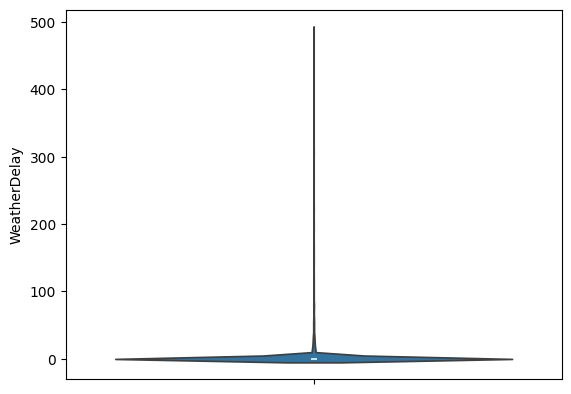

In [ ]:
sns.violinplot(df_flight["WeatherDelay"])

<Axes: ylabel='NASDelay'>

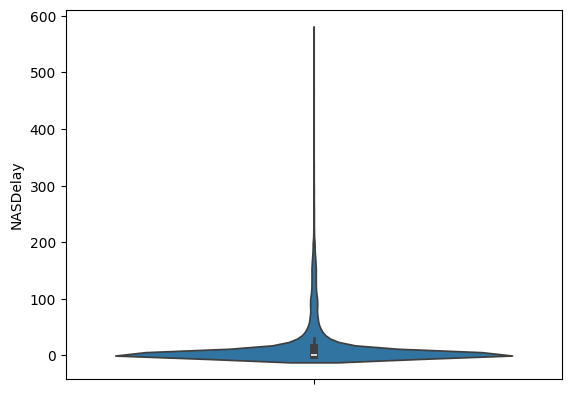

In [ ]:
sns.violinplot(df_flight["NASDelay"])

<Axes: ylabel='SecurityDelay'>

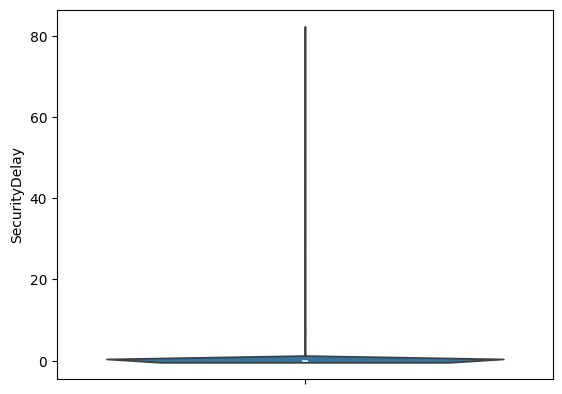

In [ ]:
sns.violinplot(df_flight["SecurityDelay"])

<Axes: ylabel='LateAircraftDelay'>

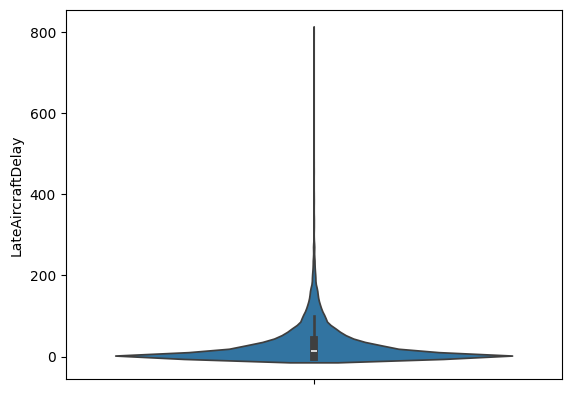

In [ ]:
sns.violinplot(df_flight["LateAircraftDelay"])

Text(0.5, 1.0, 'Top 10 Origin Airports Delayed')

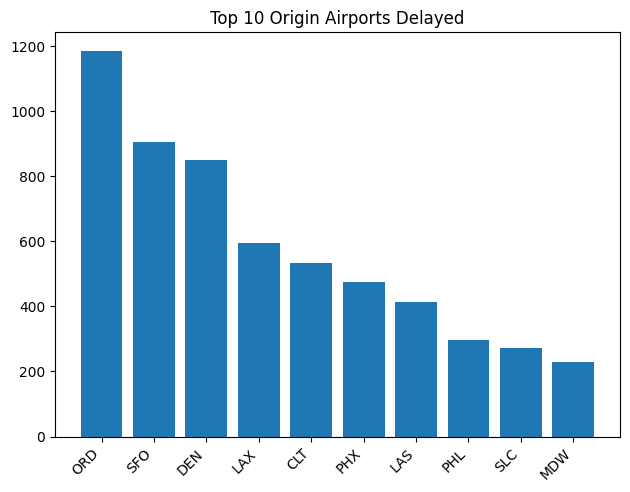

In [ ]:
#Here I did some grouped histograms

#the first histogram is wehre I grouped ArrDelay by the top Origin airports
top_delay=df_flight_fixed.groupby('Origin')["ArrDelay"].size().sort_values(ascending=False).head(10)
#print(top_delay)

plt.bar(top_delay.index, top_delay.values)
plt.xticks(rotation=45, ha="right") 
plt.tight_layout()
plt.title("Top 10 Origin Airports Delayed")


I found the data to be usable as there were no rows that were missing data. It did have outlier data but it makes sense as there are times were delays are very long or some flights that are longer than others. 

The graph showing the top 10 origin data shows that the data can be analyzed for trends that make sense. Based on the top 10 arrival and departure airports, it makes sense teh airports with the most delays are the ones most frequently used. The skew is the same as the top 10 airport arrivals and departures as its the top 10 airports. 

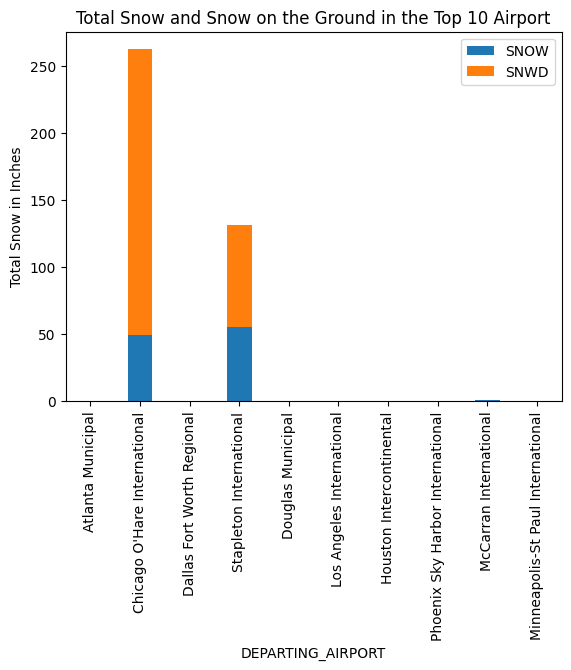

In [9]:
#This histogram groups ArrDelay by DayOfWeek
delay_cols=["SNOW", "SNWD"]
#print(top_delay)
top=df_flight["DEPARTING_AIRPORT"].value_counts().head(10).index
origin_total_delay=(df_flight[df_flight["DEPARTING_AIRPORT"].isin(top)].groupby("DEPARTING_AIRPORT")[delay_cols].sum().loc[top])
#print(origin_total_delay)

ax=origin_total_delay.plot(kind="bar", stacked=True)
ax.set_title("Total Snow and Snow on the Ground in the Top 10 Airport")
ax.set_ylabel("Total Snow in Inches")
plt.legend()



Another conclusion I was able to make was that each airport may have its problems that create delays. It is not a linear trend where having the most arrival and departures mean the total delays will be in linear order. The distribution is skewed right but unlike the the count of delays in the top 10 airport and the top 10 arrival and departure airports, the length of delay is not consistent. For example, LAX has a longer delay than PHX and SAN has a longer dealy than BWI. You can see that carrier delay has the most common delay but some airports have NAS delays more than others. So I would say the distributions are not normal. The minimum and maximum show you the total delays by minutes. 

Overall, the data looks usable for exploring flight patterns and delays. The columns match what you would expect in airline on time data like flight times, elapsed time, distance, etc. The data is waht I expected as most delays were not long between 0-60 minutes with a few extreme outliers. Busiest airports show up as the most delays which is expected. The data is usable but with one important limitation in that all the flight data was from Southwest Airlines and only 10,000 rows of the data. This is good to understand teh dat but this is just a slice of it.

Text(0.5, 1.0, 'Count of Each Airline')

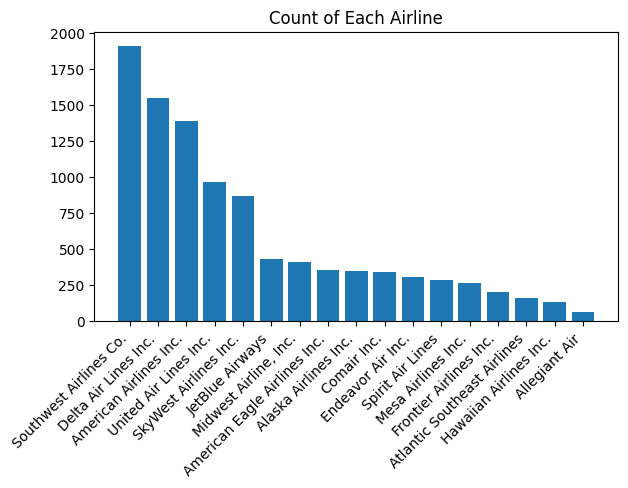

In [ ]:
unique_airline=df_flight["CARRIER_NAME"].unique
df_flight_fixed = df_flight
one_hot = pd.get_dummies(df_flight["CARRIER_NAME"], dtype=int)
df_flight_fixed = df_flight.join(one_hot)
#df_flight_fixed.iloc[0:5]

top_airline=df_flight_fixed["CARRIER_NAME"].value_counts() #Too many locations to put on the histogram, so I limited it to the top 10
plt.bar(top_airline.index, top_airline.values)
plt.xticks(rotation=45, ha="right") 
plt.tight_layout()
plt.title("Count of Each Airline")

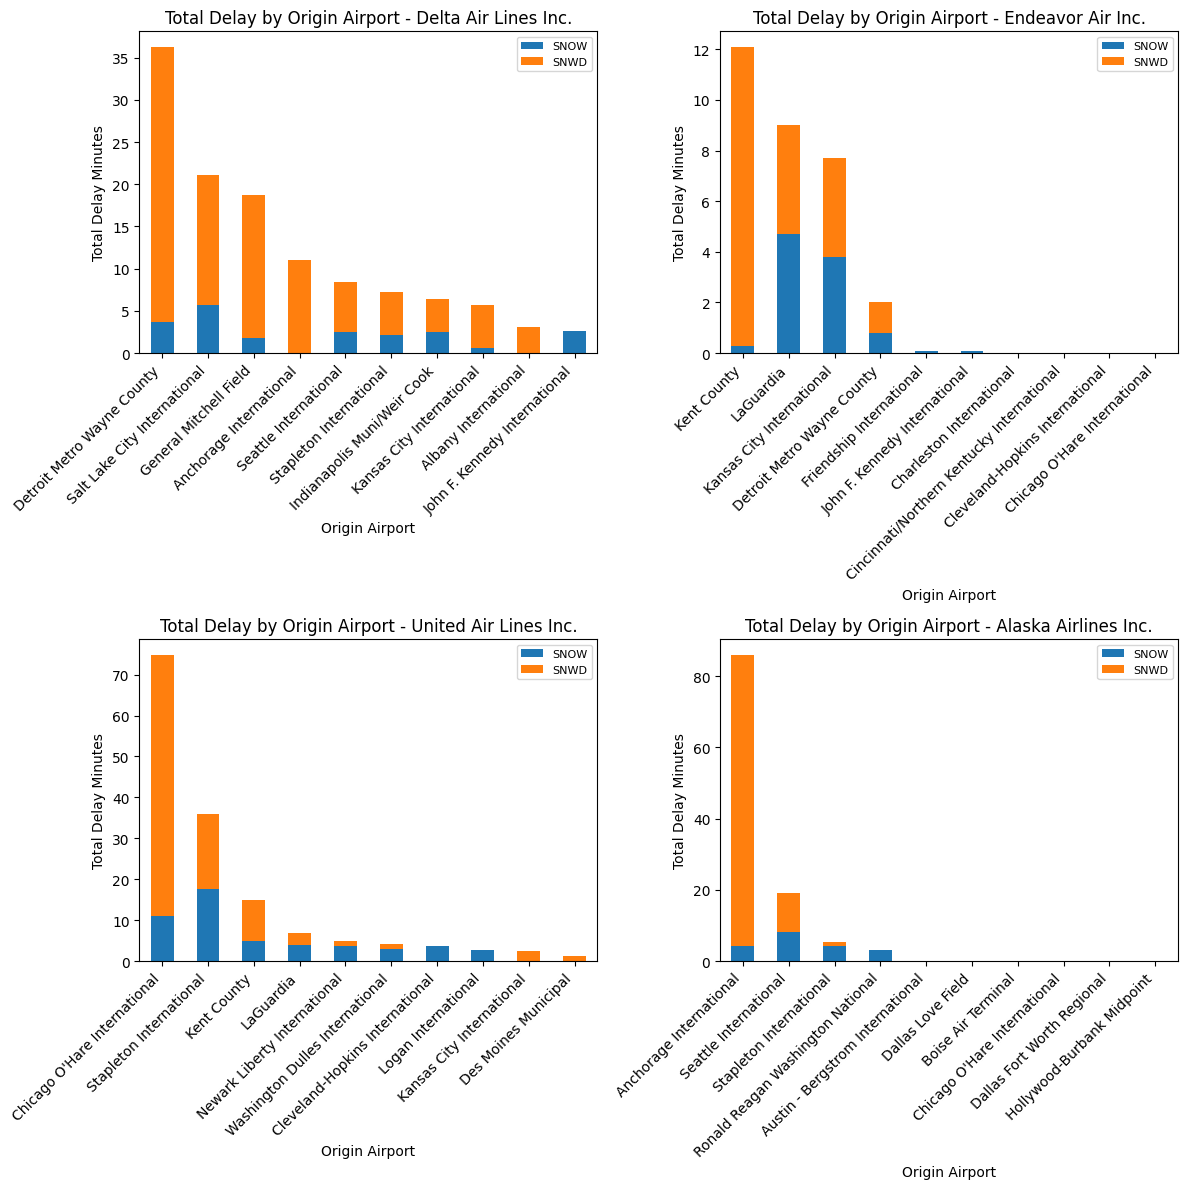

In [10]:
airlines=df_flight["CARRIER_NAME"].dropna().unique()

#fig, axes = plt.subplots(len(airlines), 1, figsize=(12, 24), sharex=True)
fig, axes = plt.subplots(2, 2, figsize=(12, 12), sharex=False)
axes=axes.flatten()

for ax, carrier in zip(axes, airlines):
    df_carrier = df_flight[df_flight["CARRIER_NAME"] == carrier]

    grouped = df_carrier.groupby("DEPARTING_AIRPORT")[delay_cols].sum()

    grouped["TotalDelay"] = grouped.sum(axis=1)

    grouped=grouped.sort_values("TotalDelay", ascending=False).head(10)
    top10_airports = grouped.index.tolist()

    grouped_plot = grouped.drop(columns="TotalDelay")
    grouped_plot.plot(kind="bar", stacked=True, ax=ax)

    #grouped.plot(kind="bar", stacked=True, ax=ax)

    ax.set_title(f"Total Delay by Origin Airport - {carrier}")
    ax.set_ylabel("Total Delay Minutes")
    ax.set_xlabel("Origin Airport")
    ax.set_xticks(range(len(top10_airports)))
    ax.set_xticklabels(top10_airports, rotation=45, ha="right")
    ax.legend(loc="upper right", fontsize=8)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 4. Storytelling With Data graph

Reproduce any graph of your choice in p. 52-68 of the Storytelling With Data book as best you can.  (The second half of chapter two).  You do not have to get the exact data values right, just the overall look and feel.

    Cats  delay 1  delay 2  delay 3
0  Cat 1        2       13       31
1  Cat 2        3       48        8
2  Cat 3       30       40       26
3  Cat 4       34        8        2
4  Cat 5       43       19       56


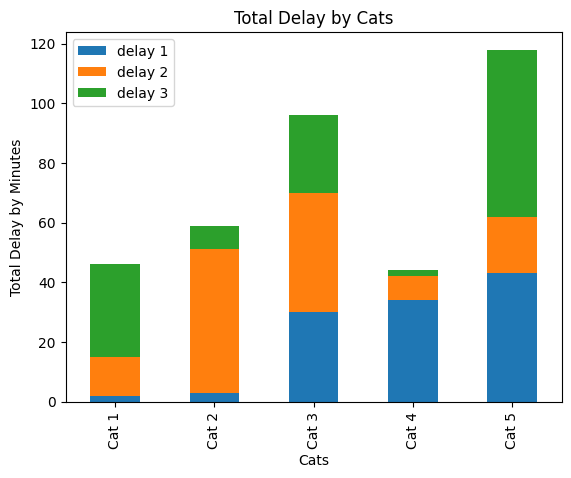

In [ ]:
df_cats = pd.DataFrame({'Cats': ["Cat 1","Cat 2", "Cat 3", "Cat 4","Cat 5"]})
df_cats["delay 1"] = pd.DataFrame(np.random.randint(0, 60,size=5))
df_cats["delay 2"]= pd.DataFrame(np.random.randint(0, 60,size=5))
df_cats["delay 3"]= pd.DataFrame(np.random.randint(0, 60,size=5))

print(df_cats)

delay_cats=["delay 1","delay 2","delay 3"]
cat_delay=(df_cats.groupby("Cats")[delay_cats].sum())
ax=cat_delay.plot(kind="bar", stacked=True)
ax.set_title("Total Delay by Cats")
ax.set_ylabel("Total Delay by Minutes")
plt.legend()